In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.arff
/kaggle/input/datasets/hassan06/nslkdd/index.html
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.txt
/kaggle/input/datas

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.arff
/kaggle/input/datasets/hassan06/nslkdd/index.html
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.txt
/kaggle/input/datas

In [3]:
import pandas as pd

train = pd.read_csv(
    "/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt",
    header=None
)

test = pd.read_csv(
    "/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt",
    header=None
)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (125973, 43)
Test Shape: (22544, 43)


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
columns = [
'duration','protocol_type','service','flag','src_bytes',
'dst_bytes','land','wrong_fragment','urgent','hot',
'num_failed_logins','logged_in','num_compromised','root_shell',
'su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate',
'srv_serror_rate','rerror_rate','srv_rerror_rate',
'same_srv_rate','diff_srv_rate','srv_diff_host_rate',
'dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate',
'dst_host_srv_diff_host_rate',
'dst_host_serror_rate',
'dst_host_srv_serror_rate',
'dst_host_rerror_rate',
'dst_host_srv_rerror_rate',
'attack',
'difficulty'
]

train.columns = columns
test.columns = columns

train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
train['attack'].value_counts()

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [6]:
train['attack'] = train['attack'].apply(
    lambda x: 0 if x == 'normal' else 1
)

test['attack'] = test['attack'].apply(
    lambda x: 0 if x == 'normal' else 1
)

print(train['attack'].value_counts())

attack
0    67343
1    58630
Name: count, dtype: int64


In [7]:
from sklearn.preprocessing import LabelEncoder

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()

    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

In [8]:
X_train = train.drop(['attack','difficulty'], axis=1)
y_train = train['attack']

X_test = test.drop(['attack','difficulty'], axis=1)
y_test = test['attack']

print(X_train.shape)
print(X_test.shape)

(125973, 41)
(22544, 41)


In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy =", accuracy)

Accuracy = 0.7706706884315118


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.66      0.97      0.78      9711
           1       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



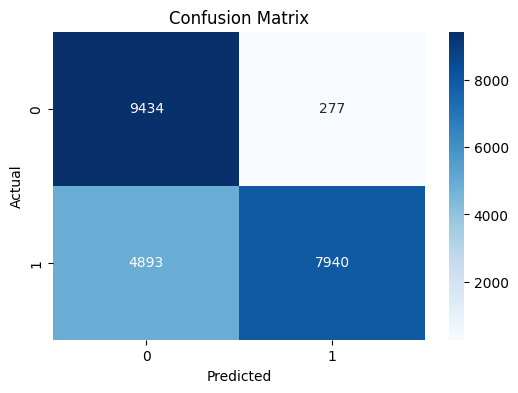

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

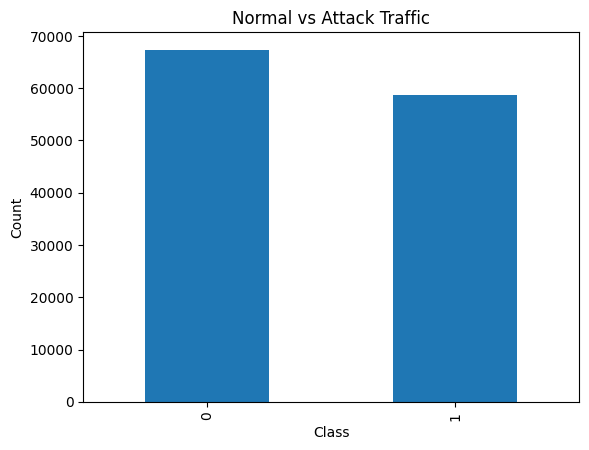

In [14]:
import matplotlib.pyplot as plt

train['attack'].value_counts().plot(
    kind='bar'
)

plt.title("Normal vs Attack Traffic")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

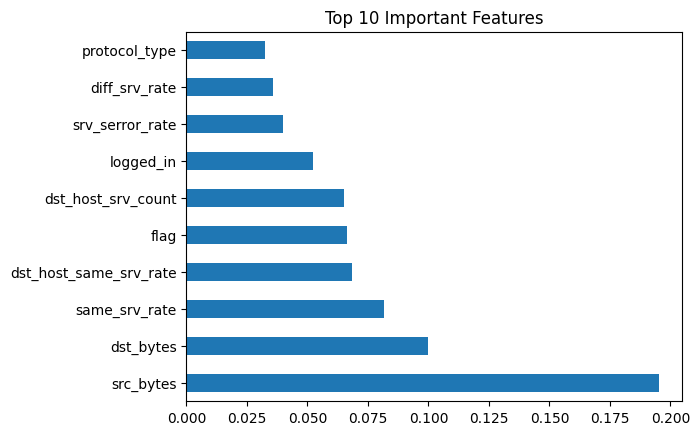

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

top10 = importance.sort_values(
    ascending=False
).head(10)

top10.plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

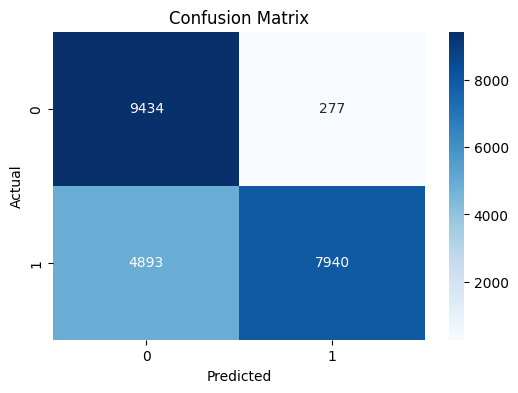

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.66      0.97      0.78      9711
           1       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544

